In [17]:
# importing packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("state_data.csv")

In [4]:
df.shape

(52, 4)

In [5]:
# 52 rows, 4 columns 

In [6]:
df.head(5)

,state,latitude,longitude,name
0,AK,63.588753,-154.493062,Alaska
1,AL,32.318231,-86.902298,Alabama
2,AR,35.201050,-91.831833,Arkansas
3,AZ,34.048928,-111.093731,Arizona
4,CA,36.778261,-119.417932,California


In [7]:
df.tail(5)

,state,latitude,longitude,name
47,VT,44.558803,-72.577841,Vermont
48,WA,47.751074,-120.740139,Washington
49,WI,43.784440,-88.787868,Wisconsin
50,WV,38.597626,-80.454903,West Virginia
51,WY,43.075968,-107.290284,Wyoming


In [8]:
# the different columns represent the state abbreviation in abc order, the latitudinal coordinate, the longitudinal coordinate, and the full state name
# the first state is Alaska
# the last state is Wyoming 
# because 2 other US territories are included

In [9]:
median_latitude = df['latitude'].median()
print(median_latitude)
# 39.4355155

median_longitude = df['longitude'].median()
print(median_longitude)
# -89.093198

df['distance_to_median_lat'] = (df['latitude']- median_latitude).abs()
df['distance_to_median_long'] = (df['longitude']- median_longitude).abs()
df

closest_lat_idx = df['distance_to_median_lat'].idxmin()
farthest_lat_idx = df['distance_to_median_lat'].idxmax()
closest_lat_state = df.loc[closest_lat_idx, 'state']
farthest_lat_state = df.loc[farthest_lat_idx, 'state']
closest_lat_dist = df.loc[closest_lat_idx, 'distance_to_median_lat']
farthest_lat_dist = df.loc[farthest_lat_idx, 'distance_to_median_lat']

print(f"Closest to median latitude: {closest_lat_state} by {closest_lat_dist:.2f} degrees")
print(f"Farthest from median latitude: {farthest_lat_state} by {farthest_lat_dist:.2f} degrees")

closest_long_idx = df['distance_to_median_long'].idxmin()
farthest_long_idx = df['distance_to_median_long'].idxmax()
closest_long_state = df.loc[closest_lat_idx, 'state']
farthest_long_state = df.loc[farthest_lat_idx, 'state']
closest_long_dist = df.loc[closest_lat_idx, 'distance_to_median_long']
farthest_long_dist = df.loc[farthest_lat_idx, 'distance_to_median_long']

print(f"Closest to median longitude: {closest_long_state} by {closest_long_dist:.2f} degrees")
print(f"Farthest from median longitude: {farthest_long_state} by {farthest_long_dist:.2f} degrees")

39.4355155
-89.093198
Closest to median latitude: CO by 0.11 degrees
Farthest from median latitude: AK by 24.15 degrees
Closest to median longitude: CO by 16.69 degrees
Farthest from median longitude: AK by 65.40 degrees


In [10]:
df.shape

(52, 6)

In [11]:
# 52 rows, 6 columns 

In [12]:
df.pivot_table(values=['latitude','longitude'], index='state', aggfunc='mean')
# I went to the user guide tab for pandas and I scrolled and found pivot_tables in the menu
# .pivot_table() summarizes data by grouping values and applying functions like mean or sum, making it easy to see patterns or comparisons across categories.

,latitude,longitude
state,,
AK,63.588753,-154.493062
AL,32.318231,-86.902298
AR,35.201050,-91.831833
AZ,34.048928,-111.093731
CA,36.778261,-119.417932
CO,39.550051,-105.782067
CT,41.603221,-73.087749
DC,38.905985,-77.033418
DE,38.910832,-75.527670


In [13]:
iris=sns.load_dataset("iris")
df=pd.DataFrame(iris)

df = df.dropna()
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [14]:
df.shape
# (150, 5)
# 150 rows, 5 columns 


(150, 5)

In [15]:
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
df.tail(5)

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


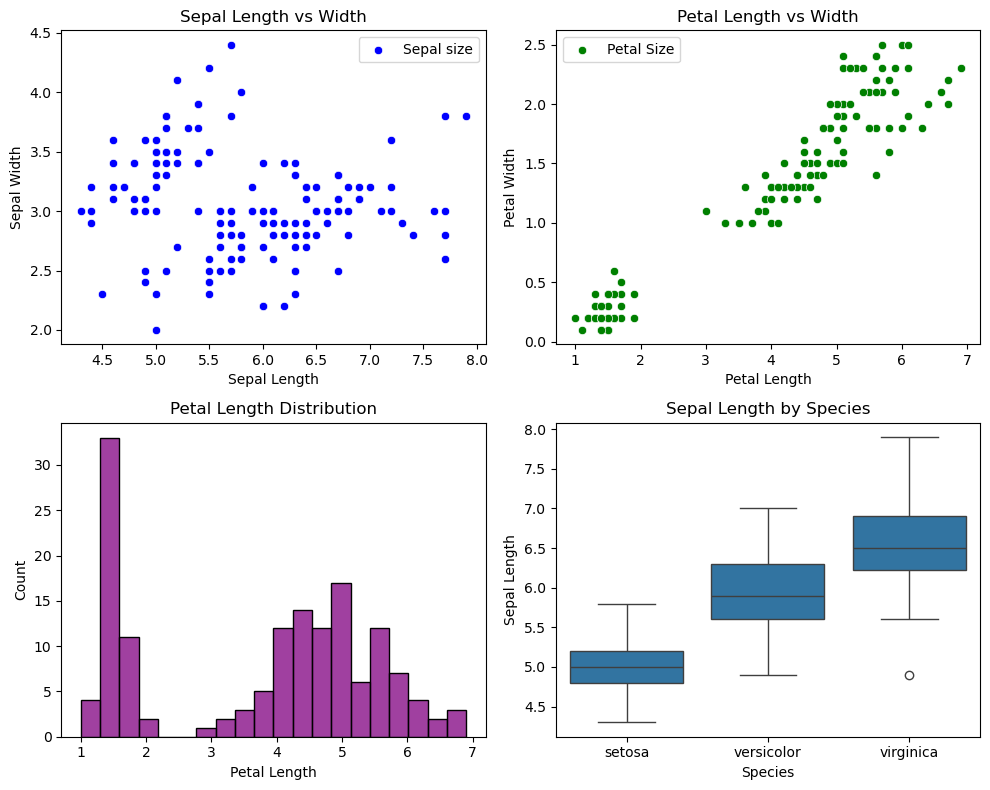

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


sns.scatterplot(
    x="sepal_length", y="sepal_width",
    data=df, ax=axes[0, 0], color="blue", label="Sepal size"
)
axes[0, 0].set_title("Sepal Length vs Width")
axes[0, 0].set_xlabel("Sepal Length")
axes[0, 0].set_ylabel("Sepal Width")
axes[0, 0].legend()



sns.scatterplot(
    x="petal_length", y="petal_width",
    data=df, ax=axes[0, 1], color="green", label="Petal Size"
)
axes[0, 1].set_title("Petal Length vs Width")
axes[0, 1].set_xlabel("Petal Length")
axes[0, 1].set_ylabel("Petal Width")

sns.histplot(
    df["petal_length"], ax=axes[1, 0], color="purple", bins=20
)
axes[1, 0].set_title("Petal Length Distribution")
axes[1, 0].set_xlabel("Petal Length")
axes[1, 0].set_ylabel("Count")

sns.boxplot(
    x="species", y="sepal_length",
    data=df, ax=axes[1, 1]
)
axes[1, 1].set_title("Sepal Length by Species")
axes[1, 1].set_xlabel("Species")
axes[1, 1].set_ylabel("Sepal Length")

plt.tight_layout()
plt.show()

In [ ]:
# the chart does not identify the units 

In [ ]:
# Explain what data each of your subplots represents and why you decided on those columns.
# subplot 1: shows the relationship between the sepal length and width, I chose them because the resulting points represent the size of the sepals
# subplot 2: shows the relationship between the petal length and width, I chose these together for the same reason as the sepal data
# subplot 3: shows the commonality of petal lengths among the data, I chose this to see what petal lengths were the most common
# subplot 4: shows the range of sepal lengths among different species, I wanted to see if there were patterns 

# What did you learn about your dataset from each subplot?
# I learned that there doesn't seem to be a correlation between sepal length and width, but as petal length increases, the width does as well. I learned that the most common petal length is between 1 and 2 (units are not stated). I learned the average sepl length is smallest in the setosa species, larger in versicolor species and largest in virginica species with one outlier.
